In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
toydata = np.load("/Users/tobiasshin/Desktop/machine learning/berkeley hw/hw1/data/toy-data.npz")

toydata

NpzFile '/Users/tobiasshin/Desktop/machine learning/berkeley hw/hw1/data/toy-data.npz' with keys: training_data, training_labels, test_data

In [14]:
#Plot data points

def plot_data_points(data, labels):
    plt.scatter(data[:,0], data[:,1], c=labels)

#Plot decision boundary
def plot_decision_boundary(w,b):
    x = np.linspace(-5,5,100)
    y = -(w[0]*x + b) / w[1]
    plt.plot(x,y,'k')

def plot_margins(w,b):
    x = np.linspace(-5,5,100)
    y1 = -(w[0]*x + b - 1)/w[1]
    y2 = -(w[0]*x + b + 1)/w[1]
    plt.plot(x, y1, 'k--')
    plt.plot(x, y2, 'k--')


In [4]:
print(toydata.files)

['training_data', 'training_labels', 'test_data']


In [11]:
Xtrain = toydata['training_data']
Xlabels = toydata['training_labels']

Xtrain

array([[ 4.76405235,  3.40015721],
       [ 3.97873798,  5.2408932 ],
       [ 4.86755799,  2.02272212],
       ...,
       [-2.80217183, -2.9022492 ],
       [-1.59847658, -2.84156615],
       [-4.14190142, -4.31097037]])

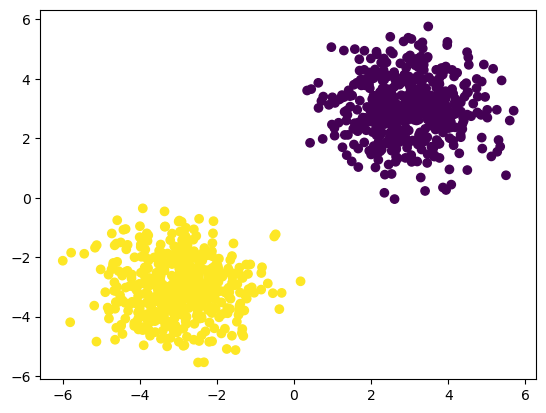

In [12]:
plot_data_points(Xtrain,labels=Xlabels)

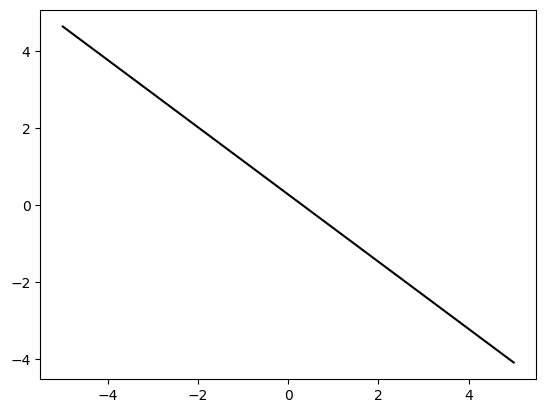

In [13]:
plot_decision_boundary([-0.4528, -0.5190], 0.1471)

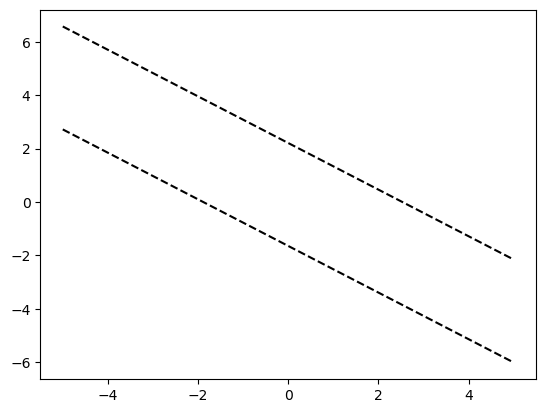

In [15]:
w = [-0.4528, -0.5190]
b = 0.1471
plot_margins(w,b)

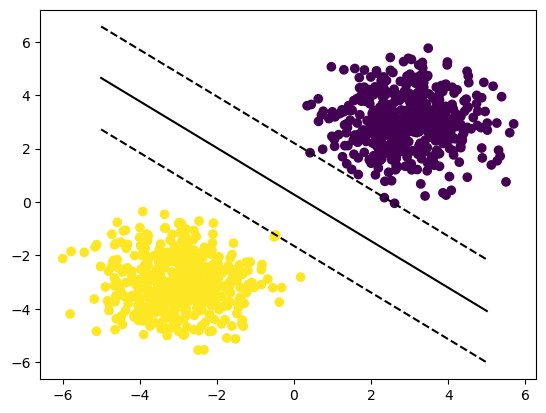

In [16]:
plot_data_points(Xtrain, labels=Xlabels)
plot_decision_boundary(w,b)
plot_margins(w,b)

plt.show()

In [17]:
mnist = np.load("/Users/tobiasshin/Desktop/machine learning/berkeley hw/hw1/data/mnist-data.npz")

In [19]:
print(mnist.files)

['training_data', 'training_labels', 'test_data']


In [34]:
#Set aside n training data points as a validation set
def train_val_split_size(images, labels, val_size=10000, seed=42):
    n = len(images)
    assert len(labels) == n, "images and labels must have same length"
    assert val_size < n, "val_size must be smaller than dataset size"

    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)

    val_idx = indices[:val_size]
    train_idx = indices[val_size:]
    X_val = images[val_idx]
    y_val = labels[val_idx]

    X_train = images[train_idx]
    y_train = labels[train_idx]

    return X_train, y_train, X_val, y_val


def train_val_split_ratio(images, labels, val_ratio=0.2, seed=42):
    n = len(images)
    assert len(labels) == n, "images and labels must have same length"
    val_size = int(n*val_ratio)
    assert val_size < n, "val_size must be smaller than dataset size"

    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)

    val_idx = indices[:val_size]
    train_idx = indices[val_size:]
    X_val = images[val_idx]
    y_val = labels[val_idx]

    X_train = images[train_idx]
    y_train = labels[train_idx]

    return X_train, y_train, X_val, y_val


In [22]:
def classification_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [23]:
mnist_train = mnist['training_data']
mnist_trainlabels = mnist['training_labels']
mnist_test = mnist['test_data']

In [24]:
from sklearn import svm 

In [25]:
clf = svm.SVC()

In [26]:
X_train, y_train, X_val, y_val = train_val_split_size(mnist_train, mnist_trainlabels)

In [29]:
X_val_flat = X_val.reshape(X_val.shape[0], -1)
y_val = y_val.ravel()

In [30]:
sizes = [100, 200, 500, 1000, 2000, 5000, 10000]

for n in sizes:
    X_trainsub = X_train[:n].reshape(n, -1)
    y_trainsub = y_train[:n].ravel()

    clf.fit(X_trainsub, y_trainsub)
    y_pred = clf.predict(X_val_flat)

    acc = classification_accuracy(y_val, y_pred)
    print(n, acc)

100 0.6404
200 0.756
500 0.8773
1000 0.9143
2000 0.935
5000 0.9492
10000 0.9584


In [31]:
spam = np.load("/Users/tobiasshin/Desktop/machine learning/berkeley hw/hw1/data/spam-data.npz")

In [32]:
print(spam.files)

['training_data', 'training_labels', 'test_data']


In [35]:
spamX_train, spamy_train, spamX_val, spamy_val = train_val_split_ratio(spam['training_data'], spam['training_labels'])

In [36]:
sizes = [100, 200, 500, 1000, 2000, len(spamX_train)]

for n in sizes:
    X_trainsub = spamX_train[:n]
    y_trainsub = spamy_train[:n]

    clf.fit(X_trainsub, y_trainsub)
    y_pred = clf.predict(spamX_val)

    acc = classification_accuracy(spamy_val, y_pred)
    print(n, acc)

100 0.762589928057554
200 0.7577937649880095
500 0.7721822541966427
1000 0.7913669064748201
2000 0.7985611510791367
3337 0.8081534772182254


In [38]:
X_trainsub = X_train[:10000].reshape(10000, -1)
y_trainsub = y_train[:10000].ravel()
C_vals = [0.1, 1, 10, 100, 1000]

for c in C_vals:
    clf = svm.SVC(C=c)
    clf.fit(X_trainsub, y_trainsub)
    y_pred = clf.predict(X_val_flat)

    acc = classification_accuracy(y_val, y_pred)
    print(c, acc)

0.1 0.9297
1 0.9584
10 0.9658
100 0.9658
1000 0.9658


In [47]:
def k_fold_split(images, labels, k=5, seed=42):
    n = len(images)
    assert len(labels) == n

    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)

    folds = np.array_split(indices, k)

    return folds



In [48]:

def cross_validate_svm(images, labels, C_vals, k=5):
    folds = k_fold_split(images, labels, k)
    results = {}

    for C in C_vals:
        fold_accuracies = []
        for i in range(k):
            val_idx = folds[i]
            train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

            X_train = images[train_idx]
            y_train = labels[train_idx]
            X_val = images[val_idx]
            y_val = labels[val_idx]

            X_train = X_train.reshape(len(X_train), -1) / 255.0
            X_val = X_val.reshape(len(X_val), -1) / 255.0

            y_train = y_train.ravel()
            y_val = y_val.ravel()

            clf = svm.SVC(C=C)
            clf.fit(X_train,y_train)

            y_pred = clf.predict(X_val)
            acc = np.mean(y_val == y_pred)

            fold_accuracies.append(acc)
        
        avg_acc = np.mean(fold_accuracies)
        results[C] = avg_acc
        
        print(f"C={C}, fold_accs={fold_accuracies}, avg={avg_acc:.4f}")
    
    return results



In [49]:
C_vals = [0.1, 1, 10, 100, 1000]

results = cross_validate_svm(spam['training_data'],spam['training_labels'],C_vals,k=5)

C=0.1, fold_accs=[0.770059880239521, 0.7613908872901679, 0.7565947242206235, 0.7182254196642686, 0.7673860911270983], avg=0.7547
C=1, fold_accs=[0.8083832335329342, 0.7877697841726619, 0.7961630695443646, 0.7721822541966427, 0.7985611510791367], avg=0.7926
C=10, fold_accs=[0.8311377245508982, 0.802158273381295, 0.815347721822542, 0.7937649880095923, 0.8105515587529976], avg=0.8106
C=100, fold_accs=[0.8550898203592814, 0.8225419664268585, 0.8237410071942446, 0.8093525179856115, 0.8369304556354916], avg=0.8295
C=1000, fold_accs=[0.8479041916167664, 0.8261390887290168, 0.8249400479616307, 0.8189448441247003, 0.8309352517985612], avg=0.8298


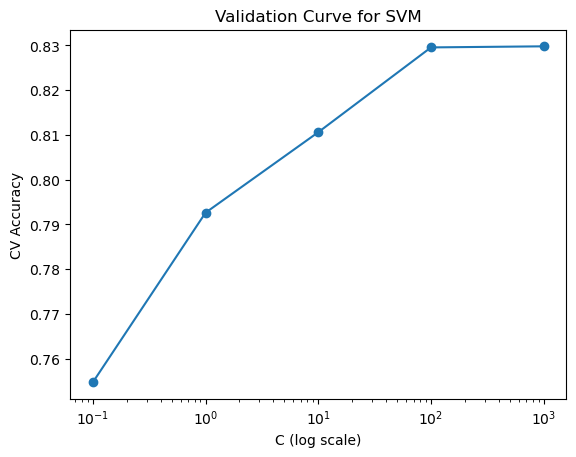

In [50]:
Cs = list(results.keys())
accs = list(results.values())

plt.plot(Cs, accs, marker='o')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('CV Accuracy')
plt.title('Validation Curve for SVM')
plt.show()

In [51]:
def results_to_csv(y_test, file_name):
    y_test = y_test.astype(int)
    df = pd.DataFrame({'Category': y_test})
    df.index += 1
    df.to_csv(file_name, index_label='Id')

In [ ]:
mnist_train_flat = mnist_train.reshape(len(mnist_train), -1) / 255.0
mnist_test_flat = mnist_test.reshape(len(mnist_test), -1) / 255.0
mnist_trainlabels = mnist_trainlabels.ravel()

clf = svm.SVC(C=10)
clf.fit(mnist_train_flat, mnist_trainlabels)

mnist_pred = clf.predict(mnist_test_flat)
results_to_csv(mnist_pred, "mnist_submission.csv")

In [55]:
spam_train = spam['training_data']
spam_test = spam['test_data']
spam_trainlabels = spam['training_labels']

clf = svm.SVC(C=100)
clf.fit(spam_train, spam_trainlabels)

spam_pred = clf.predict(spam_test)
results_to_csv(spam_pred, "spam_submission.csv")